In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [23]:
df = pd.read_csv('fertilizer.csv')
print('Dataset loaded. Shape:', df.shape)
df.head()

Dataset loaded. Shape: (205, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


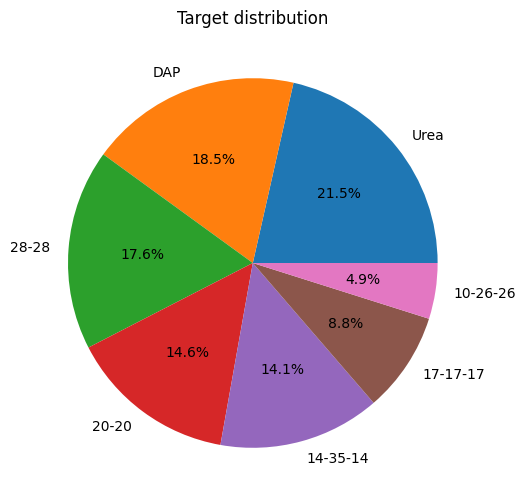

In [24]:
labels = df['Fertilizer Name'].value_counts().index.tolist()
counts = df['Fertilizer Name'].value_counts().values
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(counts, labels=labels, autopct='%1.1f%%')
ax.set_title('Target distribution')
plt.show()

In [25]:
print(df.columns)

Index(['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')


In [26]:
features = ['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type','Nitrogen', 'Potassium', 'Phosphorous']
target = 'Fertilizer Name'
X = df[features]
y = df[target]

In [27]:
# X = df[features].copy()

soil_encoder = LabelEncoder()
crop_encoder = LabelEncoder()
y_encoder = LabelEncoder()

X['Soil Type'] = soil_encoder.fit_transform(X['Soil Type'])
X['Crop Type'] = crop_encoder.fit_transform(X['Crop Type'])
y_encoded = y_encoder.fit_transform(y)

C:\Users\karth\AppData\Local\Temp\ipykernel_2044\717614708.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Soil Type'] = soil_encoder.fit_transform(X['Soil Type'])
C:\Users\karth\AppData\Local\Temp\ipykernel_2044\717614708.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Crop Type'] = crop_encoder.fit_transform(X['Crop Type'])


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
# Build a deeper model with BatchNorm and Dropout
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_scaled.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(len(np.unique(y_encoded)), activation='softmax'))

optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\karth\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,615 (49.28 KB)

 Trainable params: 12,167 (47.53 KB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
# Callbacks: save best model, early stopping and reduce LR on plateau
model_name = 'best_weights.h5'
checkpoint = ModelCheckpoint(model_name, monitor='val_loss', mode='min', save_best_only=True, verbose=1)
earlystopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)

callbacks = [checkpoint, earlystopping, reduce_lr]

# Training: include class weights and validation split
history = model.fit(
    X_scaled, y_encoded,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.0625 - loss: 2.7712
Epoch 1: val_loss improved from None to 1.89705, saving model to best_weights.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.1159 - loss: 2.5153 - val_accuracy: 0.0976 - val_loss: 1.8970 - learning_rate: 0.0010
Epoch 2/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 2s 562ms/step - accuracy: 0.1875 - loss: 2.2265
Epoch 2: val_loss improved from 1.89705 to 1.84439, saving model to best_weights.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.2378 - loss: 2.0930 - val_accuracy: 0.3902 - val_loss: 1.8444 - learning_rate: 0.0010
Epoch 3/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3750 - loss: 1.6502
Epoch 3: val_loss improved from 1.84439 to 1.79892, saving model to best_weights.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3902 - loss: 1.7392 - val_accuracy: 0.4634 - val_loss: 1.7989 - learning_rate: 0.0010
Epoch 4/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2500 - loss: 1.9737
Epoch 4: val_loss improved from 1.79892 to 1.75546, saving model to best_weights.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3659 - loss: 1.7989 - val_accuracy: 0.4878 - val_loss: 1.7555 - learning_rate: 0.0010
Epoch 5/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6250 - loss: 1.1747
Epoch 5: val_loss improved from 1.75546 to 1.71628, saving model to best_weights.h5


...

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9207 - loss: 0.2420 - val_accuracy: 1.0000 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 97/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9375 - loss: 0.1784
Epoch 97: val_loss improved from 0.02531 to 0.02524, saving model to best_weights.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9268 - loss: 0.2264 - val_accuracy: 1.0000 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 98/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9688 - loss: 0.1571
Epoch 98: val_loss improved from 0.02524 to 0.02411, saving model to best_weights.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9573 - loss: 0.1927 - val_accuracy: 1.0000 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 99/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9688 - loss: 0.1480
Epoch 99: val_loss improved from 0.02411 to 0.02380, saving model to best_weights.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9756 - loss: 0.1539 - val_accuracy: 1.0000 - val_loss: 0.0238 - learning_rate: 0.0010
Epoch 100/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8750 - loss: 0.2759
Epoch 100: val_loss improved from 0.02380 to 0.02361, saving model to best_weights.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9268 - loss: 0.2256 - val_accuracy: 1.0000 - val_loss: 0.0236 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 100.


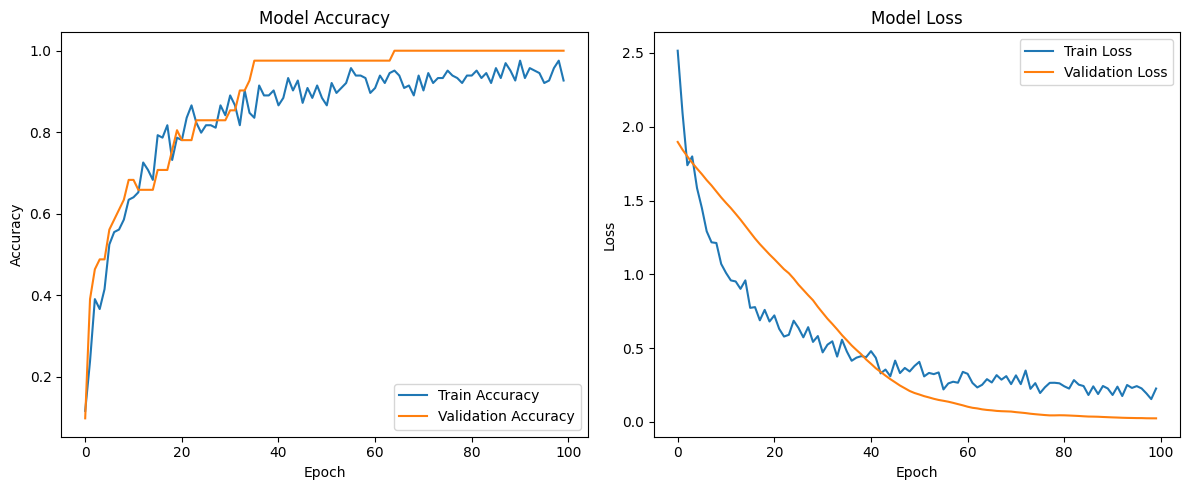

In [31]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
model.save('fertilizer_model.h5')
print('Saved model to fertilizer_model.h5')
import joblib
joblib.dump(model, 'ferti_new.joblib')

Saved model to fertilizer_model.h5


['ferti_new.joblib']

In [33]:
# Predict class probabilities for all samples
y_pred_prob = model.predict(X_scaled)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert encoded labels back to original fertilizer names
y_pred_labels = y_encoder.inverse_transform(y_pred)
y_true_labels = y_encoder.inverse_transform(y_encoded)

# Create a DataFrame to compare true and predicted values
results = pd.DataFrame({
    'Actual': y_true_labels,
    'Predicted': y_pred_labels
})

print(results.head())


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
     Actual Predicted
0      Urea      Urea
1       DAP       DAP
2  14-35-14  14-35-14
3     28-28     28-28
4      Urea      Urea


In [34]:
def predict_from_user():
    # Get input from user
    temperature = float(input("Enter temperature: "))
    humidity = float(input("Enter humidity: "))
    moisture = float(input("Enter moisture: "))
    nitrogen = float(input("Enter nitrogen content: "))
    potassium = float(input("Enter potassium content: "))
    phosphorous = float(input("Enter phosphorous content: "))
    soil_type = input("Enter soil type (e.g., Sandy, Loamy): ")
    crop_type = input("Enter crop type (e.g., Maize, Rice): ")

    # Prepare the input as DataFrame
    data = {
        'Temparature': [temperature],
        'Humidity ': [humidity],
        'Moisture': [moisture],
        'Soil Type': [soil_encoder.transform([soil_type])[0]],
        'Crop Type': [crop_encoder.transform([crop_type])[0]],
        'Nitrogen': [nitrogen],
        'Potassium': [potassium],
        'Phosphorous': [phosphorous]
    }
    X_new = pd.DataFrame(data)

    # Scale the input
    X_scaled_new = scaler.transform(X_new)

    # Predict
    pred_prob = model.predict(X_scaled_new)
    pred_class = np.argmax(pred_prob, axis=1)
    fertilizer = y_encoder.inverse_transform(pred_class)[0]

    print(f"Recommended Fertilizer: {fertilizer}")

# Call the function
predict_from_user()


Enter temperature:  29
Enter humidity:  52
Enter moisture:  45
Enter nitrogen content:  12
Enter potassium content:  0
Enter phosphorous content:  36
Enter soil type (e.g., Sandy, Loamy):  Loamy
Enter crop type (e.g., Maize, Rice):  Sugarcane


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Recommended Fertilizer: DAP


In [20]:
def predict_fertilizer_safe(temperature, humidity, moisture, nitrogen, potassium, phosphorous, soil_type, crop_type):
    # Handle unseen soil type
    if soil_type in soil_encoder.classes_:
        soil_encoded = soil_encoder.transform([soil_type])[0]
    else:
        print(f"Warning: Soil type '{soil_type}' not seen in training. Using default value.")
        soil_encoded = 0  # default to first class or most common

    # Handle unseen crop type
    if crop_type in crop_encoder.classes_:
        crop_encoded = crop_encoder.transform([crop_type])[0]
    else:
        print(f"Warning: Crop type '{crop_type}' not seen in training. Using default value.")
        crop_encoded = 0  # default to first class or most common

    # Prepare input as DataFrame
    data = {
        'Temparature': [temperature],
        'Humidity ': [humidity],
        'Moisture': [moisture],
        'Soil Type': [soil_encoded],
        'Crop Type': [crop_encoded],
        'Nitrogen': [nitrogen],
        'Potassium': [potassium],
        'Phosphorous': [phosphorous]
    }
    X_new = pd.DataFrame(data)

    # Scale features
    X_new_scaled = scaler.transform(X_new)

    # Predict
    y_pred = model.predict(X_new_scaled)
    fertilizer_label = y_encoder.inverse_transform([np.argmax(y_pred)])
    return fertilizer_label[0]


In [21]:
# Get user input
temperature = float(input("Enter temperature: "))
humidity = float(input("Enter humidity: "))
moisture = float(input("Enter moisture: "))
nitrogen = float(input("Enter nitrogen content: "))
potassium = float(input("Enter potassium content: "))
phosphorous = float(input("Enter phosphorous content: "))
soil_type = input("Enter soil type (e.g., Sandy, Loamy, Clay): ")
crop_type = input("Enter crop type (e.g., Maize, Rice, Wheat): ")

# Make prediction safely
result = predict_fertilizer_safe(temperature, humidity, moisture, nitrogen, potassium, phosphorous, soil_type, crop_type)
print("Recommended Fertilizer:", result)

Enter temperature:  30
Enter humidity:  45
Enter moisture:  20
Enter nitrogen content:  50
Enter potassium content:  20
Enter phosphorous content:  10
Enter soil type (e.g., Sandy, Loamy, Clay):  Sandy
Enter crop type (e.g., Maize, Rice, Wheat):  Maize


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Recommended Fertilizer: 17-17-17
